In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.sparse.csgraph import minimum_spanning_tree

In [ ]:
RET_MAT_PATH = "data_prepared/ret_mat.csv" #from prepare_stock_data.py
META_PATH = "data_prepared/meta.csv" #from prepare_stock_data.py

ret_mat = pd.read_csv(RET_MAT_PATH, index_col=0)
ret_mat.index = pd.to_datetime(ret_mat.index)

meta = pd.read_csv(META_PATH, index_col=0)

print("ret_mat shape:", ret_mat.shape)
print("meta shape:", meta.shape)

ret_mat.head()

ret_mat shape: (1004, 100)
meta shape: (100, 10)


,AAL,AAPL,ABEV,AMC,AMD,AMZN,ARKK,BABA,BAC,BMY,...,UVXY,VALE,VZ,WFC,XLE,XLF,XLP,XLU,XOM,XPEV
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.019828,0.012364,0.023411,-0.014925,0.005092,0.010004,0.024621,0.055080,0.007659,0.002770,...,-0.046550,0.016667,-0.004588,0.027946,0.044784,0.004470,0.000000,-0.000164,0.048193,-0.039909
2021-01-05,0.005833,-0.033662,0.003268,0.015152,-0.026302,-0.024897,0.003679,-0.053203,0.062459,0.002437,...,-0.010462,0.026569,0.012120,0.070750,0.030509,0.044163,0.000749,0.024873,0.025517,-0.026216
2021-01-06,-0.009021,0.034123,-0.026059,0.019900,0.053471,0.007577,0.079155,-0.003119,0.022084,0.010697,...,-0.088106,0.042401,-0.002235,0.022637,0.014681,0.014426,-0.002995,-0.013093,0.007846,0.091196
2021-01-07,-0.016255,0.008631,0.026756,0.043903,-0.006095,0.006496,0.029628,0.040943,-0.010043,0.002085,...,-0.013527,-0.000528,-0.012472,-0.007179,-0.001206,-0.000646,0.004957,0.008413,0.011121,0.010224
2021-01-08,-0.008592,-0.023249,-0.035831,0.028037,0.028230,-0.021519,-0.029899,-0.037343,0.016600,0.039686,...,0.086190,-0.016385,-0.005882,0.001507,0.015693,0.003234,-0.008520,-0.009305,0.030356,-0.023982


In [3]:
LOOKBACK = 252              # rolling window, about 1 year
REBALANCE_STEP = 21         # about monthly
CORR_THRESHOLD = 0.45       # threshold graph
N_CLUSTERS = 6              # for hierarchical clustering

# choose how to color nodes
GROUP_COL = "HSICMG" if "HSICMG" in meta.columns else (
    "SICCD" if "SICCD" in meta.columns else None
)

SIZE_COL = "volume" if "volume" in meta.columns else (
    "sharesOut" if "sharesOut" in meta.columns else None
)

print("GROUP_COL =", GROUP_COL)
print("SIZE_COL =", SIZE_COL)

GROUP_COL = HSICMG
SIZE_COL = volume


In [4]:
common_cols = [c for c in ret_mat.columns if c in meta.index]
ret_mat = ret_mat[common_cols].copy()
meta = meta.loc[common_cols].copy()

ret_mat = ret_mat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

print(ret_mat.shape)
print(meta.shape)

(1004, 100)
(100, 10)


In [5]:
def compute_corr(window_returns):
    corr = window_returns.corr()
    corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    np.fill_diagonal(corr.values, 1.0)
    return corr


def corr_to_distance(corr):
    dist = np.sqrt(np.maximum(0, 2 * (1 - corr)))
    return dist


def build_threshold_graph(corr, threshold=0.45):
    G = nx.Graph()
    tickers = list(corr.columns)
    G.add_nodes_from(tickers)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            w = corr.iloc[i, j]
            if w >= threshold:
                G.add_edge(tickers[i], tickers[j], weight=w)

    return G


def build_mst_graph(corr):
    dist = corr_to_distance(corr)
    mst_sparse = minimum_spanning_tree(dist.values)
    mst_dense = mst_sparse.toarray()

    tickers = list(corr.columns)
    G = nx.Graph()
    G.add_nodes_from(tickers)

    for i in range(len(tickers)):
        for j in range(len(tickers)):
            if mst_dense[i, j] > 0:
                d = mst_dense[i, j]
                implied_corr = 1 - (d ** 2) / 2
                G.add_edge(tickers[i], tickers[j], weight=implied_corr, distance=d)

    return G

In [9]:
def hierarchical_clusters_from_corr(corr, n_clusters=6):
    dist = corr_to_distance(corr)
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method="average")
    labels = fcluster(Z, n_clusters, criterion="maxclust")
    cluster_map = pd.Series(labels, index=corr.index)
    return Z, cluster_map


def graph_communities(G):
    try:
        communities = nx.community.louvain_communities(G, seed=42, weight="weight")
    except Exception:
        communities = list(nx.community.greedy_modularity_communities(G, weight="weight"))

    cluster_map = {}
    for k, comm in enumerate(communities, start=1):
        for node in comm:
            cluster_map[node] = k

    return pd.Series(cluster_map)

In [10]:
def get_node_colors(values):
    vals = pd.Series(values).fillna("Unknown").astype(str)
    unique_vals = vals.unique()
    cmap = plt.cm.get_cmap("tab20", len(unique_vals))
    mapping = {v: cmap(i) for i, v in enumerate(unique_vals)}
    colors = vals.map(mapping)
    return colors, mapping


def get_node_sizes(meta_sub, size_col=None):
    if size_col is None or size_col not in meta_sub.columns:
        return pd.Series(300, index=meta_sub.index)

    x = pd.to_numeric(meta_sub[size_col], errors="coerce")
    x = x.fillna(x.median() if x.notna().any() else 1.0)
    x = np.log1p(x)
    x = 150 + 650 * (x / x.max() if x.max() > 0 else 1.0)
    return pd.Series(x, index=meta_sub.index)

In [11]:
end_loc = LOOKBACK + 100
window_returns = ret_mat.iloc[end_loc - LOOKBACK:end_loc].copy()
corr = compute_corr(window_returns)

G_thresh = build_threshold_graph(corr, threshold=CORR_THRESHOLD)
G_mst = build_mst_graph(corr)

Z, cluster_map_h = hierarchical_clusters_from_corr(corr, n_clusters=N_CLUSTERS)
cluster_map_g = graph_communities(G_thresh if G_thresh.number_of_edges() > 0 else G_mst)

print("Threshold graph:", G_thresh.number_of_nodes(), "nodes,", G_thresh.number_of_edges(), "edges")
print("MST graph:", G_mst.number_of_nodes(), "nodes,", G_mst.number_of_edges(), "edges")
print("Number of hierarchical clusters:", cluster_map_h.nunique())
print("Number of graph communities:", cluster_map_g.nunique())

Threshold graph: 100 nodes, 961 edges
MST graph: 100 nodes, 99 edges
Number of hierarchical clusters: 6
Number of graph communities: 12


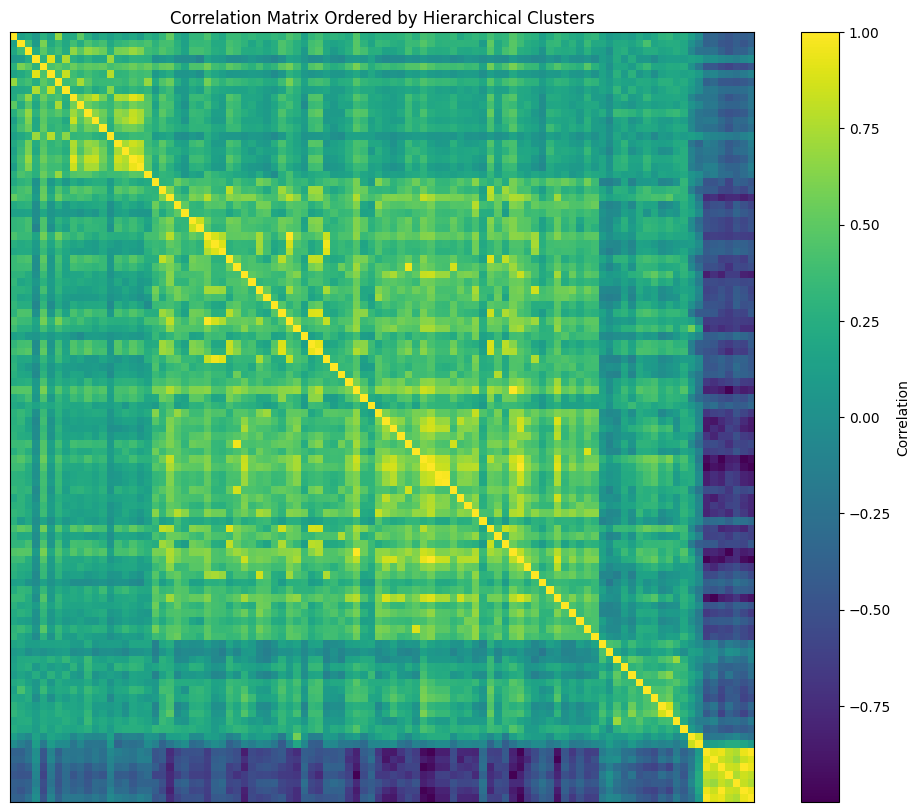

In [12]:
order = cluster_map_h.sort_values().index
corr_ord = corr.loc[order, order]

plt.figure(figsize=(12, 10))
plt.imshow(corr_ord, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix Ordered by Hierarchical Clusters")
plt.xticks([])
plt.yticks([])
plt.show()

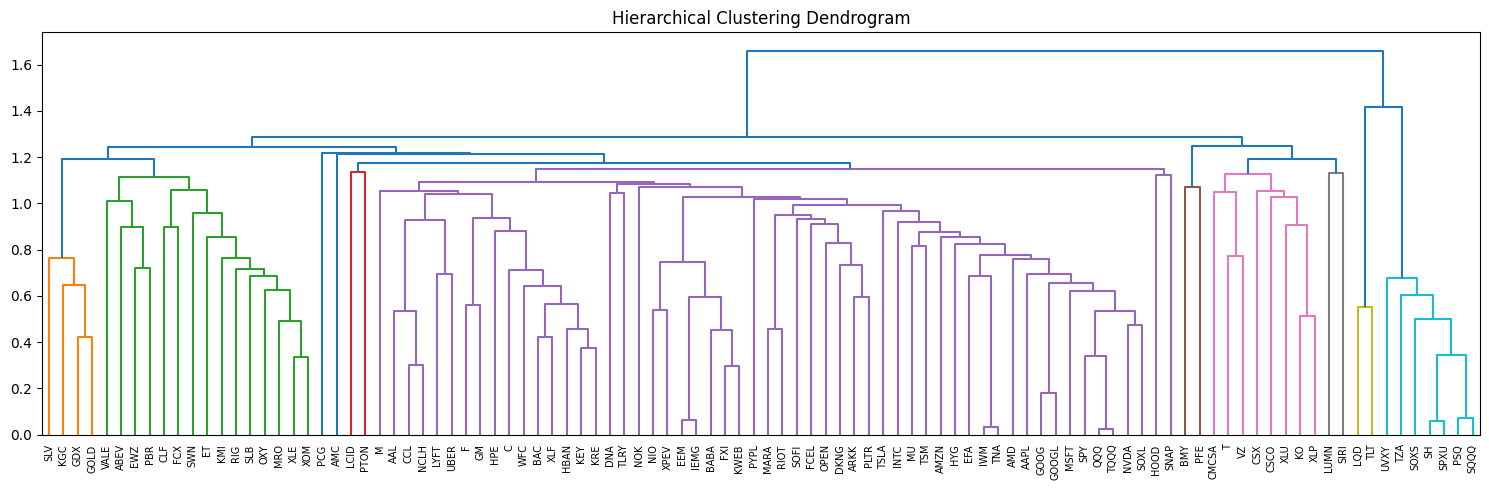

In [13]:
plt.figure(figsize=(15, 5))
dendrogram(Z, labels=corr.index.tolist(), leaf_rotation=90, leaf_font_size=7)
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()

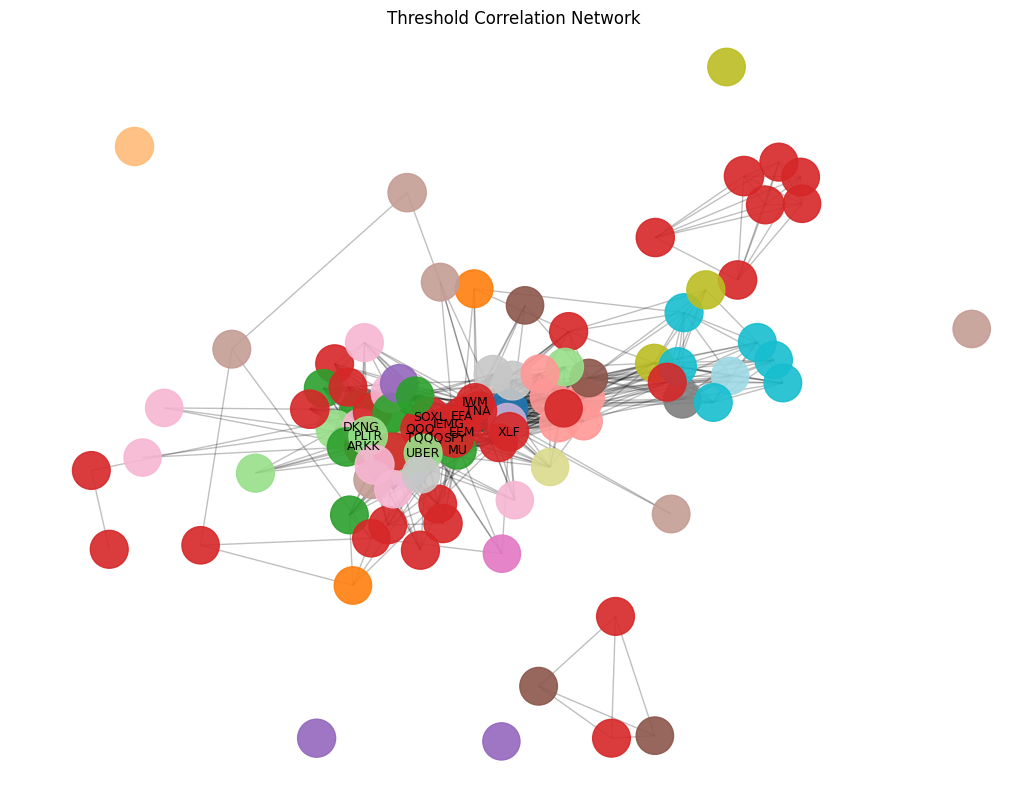

In [14]:
plot_nodes = list(G_thresh.nodes())
plot_meta = meta.reindex(plot_nodes)

if GROUP_COL is not None:
    node_colors, color_map = get_node_colors(plot_meta[GROUP_COL])
else:
    node_colors = pd.Series(["C0"] * len(plot_nodes), index=plot_nodes)

node_sizes = get_node_sizes(plot_meta, SIZE_COL)

pos = nx.spring_layout(G_thresh, seed=42, k=0.35)

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(G_thresh, pos, alpha=0.25, width=1.0)
nx.draw_networkx_nodes(
    G_thresh,
    pos,
    node_color=node_colors.tolist(),
    node_size=node_sizes.tolist(),
    alpha=0.9
)

deg = dict(G_thresh.degree())
top_labels = sorted(deg, key=deg.get, reverse=True)[:15]
labels = {n: n for n in top_labels}
nx.draw_networkx_labels(G_thresh, pos, labels=labels, font_size=9)

plt.title("Threshold Correlation Network")
plt.axis("off")
plt.show()

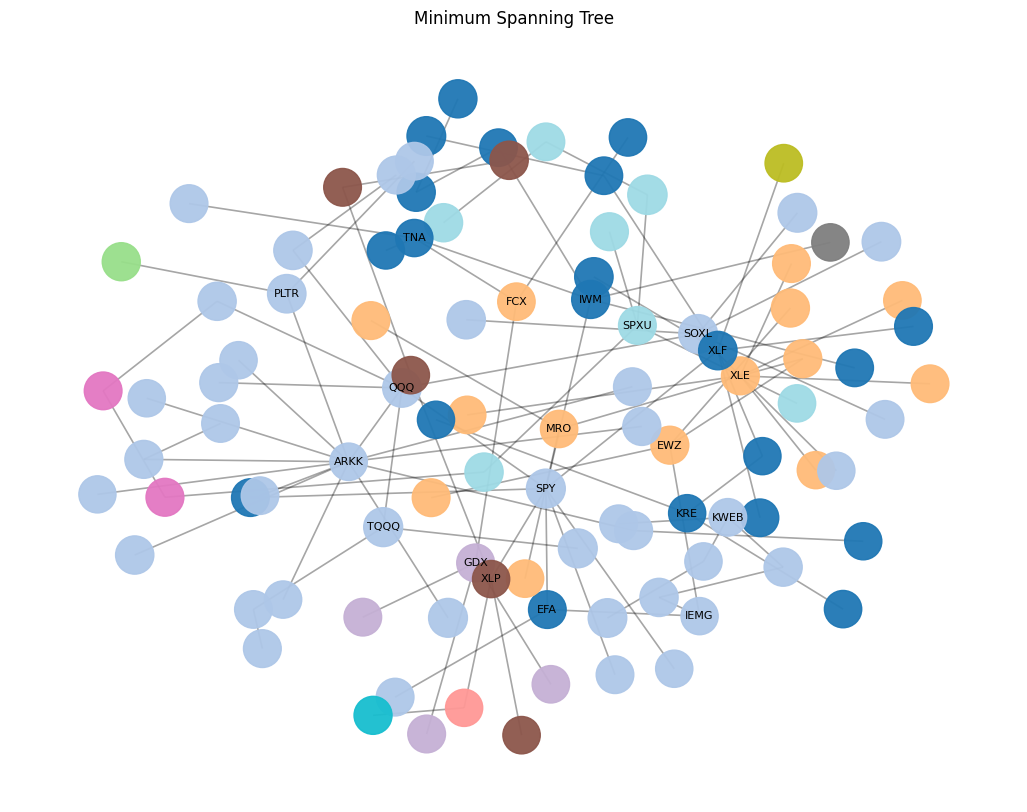

In [15]:
plot_nodes = list(G_mst.nodes())
plot_meta = meta.reindex(plot_nodes)

cluster_colors, cluster_color_map = get_node_colors(cluster_map_g.reindex(plot_nodes).fillna(-1).astype(str))
node_sizes = get_node_sizes(plot_meta, SIZE_COL)

pos = nx.spring_layout(G_mst, seed=42, k=0.4)

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(G_mst, pos, alpha=0.35, width=1.2)
nx.draw_networkx_nodes(
    G_mst,
    pos,
    node_color=cluster_colors.tolist(),
    node_size=node_sizes.tolist(),
    alpha=0.95
)

deg = dict(G_mst.degree())
top_labels = sorted(deg, key=deg.get, reverse=True)[:20]
labels = {n: n for n in top_labels}
nx.draw_networkx_labels(G_mst, pos, labels=labels, font_size=8)

plt.title("Minimum Spanning Tree")
plt.axis("off")
plt.show()

In [16]:
cluster_compare = pd.DataFrame({
    "hier_cluster": cluster_map_h,
    "graph_cluster": cluster_map_g.reindex(cluster_map_h.index)
})

if GROUP_COL is not None:
    cluster_compare[GROUP_COL] = meta.reindex(cluster_compare.index)[GROUP_COL]
    ct = pd.crosstab(cluster_compare["hier_cluster"], cluster_compare[GROUP_COL])
    print(ct)

    purity = ct.max(axis=1) / ct.sum(axis=1)
    print("\nCluster purity:")
    print(purity)
    print("\nAverage purity:", purity.mean())
else:
    print("No industry grouping column available.")

HSICMG        10.0  13.0  20.0  28.0  35.0  36.0  37.0  40.0  44.0  45.0  \
hier_cluster                                                               
1                4     6     1     0     0     0     0     0     0     0   
2                0     0     0     1     1     6     3     0     1     1   
3                0     0     0     2     0     0     0     0     0     0   
4                0     0     1     0     0     1     0     1     0     0   
5                0     0     0     0     0     0     0     0     0     0   
6                0     0     0     0     0     0     0     0     0     0   

HSICMG        48.0  49.0  51.0  53.0  56.0  60.0  67.0  73.0  78.0  99.0  
hier_cluster                                                              
1                0     2     1     0     1     0     4     0     0     0  
2                1     1     0     1     0     5    22     8     1     8  
3                0     0     0     0     0     0     0     0     0     0  
4               

In [18]:
if G_thresh.number_of_edges() > 0:
    G_for_centrality = G_thresh
else:
    G_for_centrality = G_mst

degree_centrality = pd.Series(nx.degree_centrality(G_for_centrality))
betweenness_centrality = pd.Series(nx.betweenness_centrality(G_for_centrality, weight="weight"))

if nx.is_connected(G_for_centrality):
    eigenvector_centrality = pd.Series(
        nx.eigenvector_centrality(G_for_centrality, weight="weight", max_iter=1000)
    )
else:
    largest_cc = max(nx.connected_components(G_for_centrality), key=len)
    G_lcc = G_for_centrality.subgraph(largest_cc).copy()

    eig_lcc = pd.Series(
        nx.eigenvector_centrality(G_lcc, weight="weight", max_iter=1000)
    )

    eigenvector_centrality = pd.Series(0.0, index=G_for_centrality.nodes())
    eigenvector_centrality.loc[eig_lcc.index] = eig_lcc

centrality_df = pd.DataFrame({
    "degree": degree_centrality,
    "betweenness": betweenness_centrality,
    "eigenvector": eigenvector_centrality
}).sort_values("eigenvector", ascending=False)

centrality_df.head(20)

,degree,betweenness,eigenvector
IWM,0.626263,0.047825,0.227663
TNA,0.626263,0.034632,0.226746
SPY,0.515152,0.027829,0.216782
QQQ,0.484848,0.018553,0.216657
TQQQ,0.484848,0.007009,0.216627
SOXL,0.494949,0.027829,0.211208
EFA,0.474747,0.031540,0.192852
ARKK,0.464646,0.005772,0.185618
IEMG,0.474747,0.005360,0.183257
EEM,0.464646,0.020820,0.178342


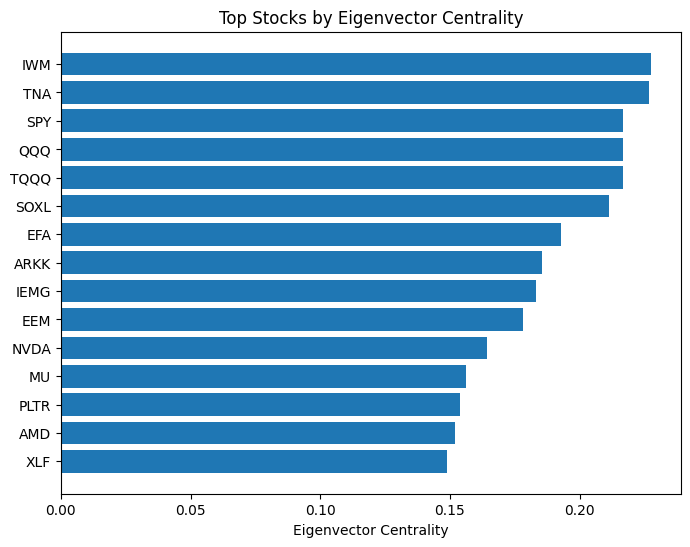

In [19]:
top_central = centrality_df["eigenvector"].head(15).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_central.index, top_central.values)
plt.title("Top Stocks by Eigenvector Centrality")
plt.xlabel("Eigenvector Centrality")
plt.show()

In [21]:
def get_window_data(ret_mat, end_loc, lookback):
    window = ret_mat.iloc[end_loc - lookback:end_loc].copy()
    window = window.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return window


def compute_network_features(window_returns, threshold=0.45, n_clusters=6):
    corr = compute_corr(window_returns)
    G = build_threshold_graph(corr, threshold=threshold)

    if G.number_of_edges() == 0:
        G = build_mst_graph(corr)

    cluster_map = graph_communities(G)
    cluster_map = cluster_map.reindex(window_returns.columns)

    if cluster_map.isna().any():
        missing = cluster_map[cluster_map.isna()].index
        next_id = int(cluster_map.dropna().max()) + 1 if cluster_map.dropna().shape[0] > 0 else 1
        for m in missing:
            cluster_map.loc[m] = next_id
            next_id += 1
        cluster_map = cluster_map.astype(int)

    try:
        centrality = pd.Series(nx.eigenvector_centrality_numpy(G, weight="weight"))
    except Exception:
        centrality = pd.Series(nx.degree_centrality(G))

    centrality = centrality.reindex(window_returns.columns).fillna(0.0)

    return corr, G, cluster_map, centrality

In [22]:
def strategy1_positions(today_returns, cluster_map, z_entry=1.0, max_pos_per_cluster=2):
    positions = pd.Series(0.0, index=today_returns.index)

    for cl in sorted(cluster_map.unique()):
        members = cluster_map[cluster_map == cl].index
        r = today_returns.reindex(members).dropna()

        if len(r) < 4:
            continue

        mu = r.mean()
        sd = r.std()
        if sd == 0 or np.isnan(sd):
            continue

        z = (r - mu) / sd

        longs = z[z <= -z_entry].sort_values().index[:max_pos_per_cluster]
        shorts = z[z >= z_entry].sort_values(ascending=False).index[:max_pos_per_cluster]

        if len(longs) > 0:
            positions.loc[longs] = 1.0 / len(longs)
        if len(shorts) > 0:
            positions.loc[shorts] = -1.0 / len(shorts)

    gross = positions.abs().sum()
    if gross > 0:
        positions = positions / gross

    return positions

In [24]:
def strategy2_positions(today_returns, cluster_map, centrality,
                        top_q=0.2, bottom_q=0.3, signal_threshold=0.0):
    positions = pd.Series(0.0, index=today_returns.index)

    c = centrality.reindex(today_returns.index).dropna()
    if len(c) < 10:
        return positions

    hub_cut = c.quantile(1 - top_q)
    periph_cut = c.quantile(bottom_q)

    hubs = c[c >= hub_cut].index
    peripherals = c[c <= periph_cut].index

    for cl in sorted(cluster_map.unique()):
        members = cluster_map[cluster_map == cl].index

        cluster_hubs = [x for x in hubs if x in members and x in today_returns.index]
        cluster_periph = [x for x in peripherals if x in members and x in today_returns.index]

        if len(cluster_hubs) == 0 or len(cluster_periph) == 0:
            continue

        hub_rets = today_returns.reindex(cluster_hubs).dropna()
        hub_cent = centrality.reindex(cluster_hubs).dropna()

        if len(hub_rets) == 0:
            continue

        weights = hub_cent / hub_cent.sum()
        signal = (hub_rets * weights).sum()

        if signal > signal_threshold:
            positions.loc[cluster_periph] = 1.0 / len(cluster_periph)
        elif signal < -signal_threshold:
            positions.loc[cluster_periph] = -1.0 / len(cluster_periph)

    gross = positions.abs().sum()
    if gross > 0:
        positions = positions / gross

    return positions

In [25]:
def perf_stats(ret_series, freq=252):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return {}

    wealth = (1 + ret_series).cumprod()
    ann_ret = wealth.iloc[-1] ** (freq / len(ret_series)) - 1
    ann_vol = ret_series.std() * np.sqrt(freq)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd = (wealth / wealth.cummax() - 1).min()

    return {
        "Ann Return": ann_ret,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    }

In [26]:
S1_Z_ENTRY = 1.0
S1_MAX_POS_PER_CLUSTER = 2

S2_TOP_Q = 0.2
S2_BOTTOM_Q = 0.3
S2_SIGNAL_THRESHOLD = 0.0

In [27]:
dates = ret_mat.index
s1_daily = pd.Series(0.0, index=dates)
s2_daily = pd.Series(0.0, index=dates)

rebalance_points = list(range(LOOKBACK, len(dates) - 1, REBALANCE_STEP))

for idx, end_loc in enumerate(rebalance_points, 1):
    if idx % 10 == 0 or idx == len(rebalance_points):
        print(f"Processing rebalance {idx}/{len(rebalance_points)}")

    window_returns = get_window_data(ret_mat, end_loc, LOOKBACK)
    if window_returns.shape[1] < 10:
        continue

    corr_t, G_t, cluster_map_t, centrality_t = compute_network_features(
        window_returns,
        threshold=CORR_THRESHOLD,
        n_clusters=N_CLUSTERS
    )

    signal_date = dates[end_loc - 1]
    hold_start = end_loc
    hold_end = min(end_loc + REBALANCE_STEP, len(dates) - 1)

    today_returns = ret_mat.loc[signal_date, window_returns.columns].fillna(0.0)

    pos1 = strategy1_positions(
        today_returns,
        cluster_map_t,
        z_entry=S1_Z_ENTRY,
        max_pos_per_cluster=S1_MAX_POS_PER_CLUSTER
    )

    pos2 = strategy2_positions(
        today_returns,
        cluster_map_t,
        centrality_t,
        top_q=S2_TOP_Q,
        bottom_q=S2_BOTTOM_Q,
        signal_threshold=S2_SIGNAL_THRESHOLD
    )

    for t in range(hold_start, hold_end + 1):
        next_date = dates[t]
        next_rets = ret_mat.loc[next_date, window_returns.columns].fillna(0.0)

        s1_daily.loc[next_date] = pos1.reindex(next_rets.index).fillna(0.0).dot(next_rets)
        s2_daily.loc[next_date] = pos2.reindex(next_rets.index).fillna(0.0).dot(next_rets)

Processing rebalance 10/36
Processing rebalance 20/36
Processing rebalance 30/36
Processing rebalance 36/36


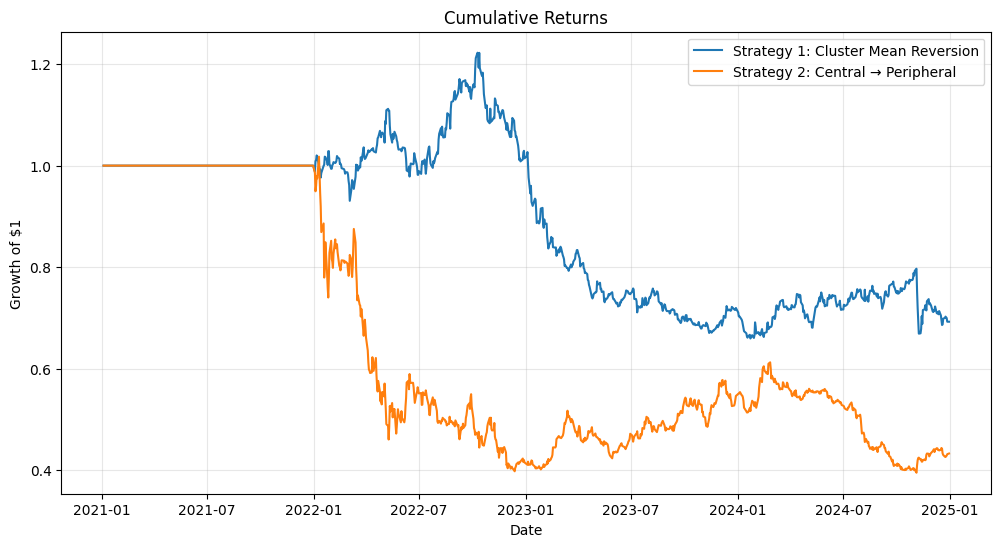

In [28]:
cum1 = (1 + s1_daily.fillna(0.0)).cumprod()
cum2 = (1 + s2_daily.fillna(0.0)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum1.index, cum1.values, label="Strategy 1: Cluster Mean Reversion")
plt.plot(cum2.index, cum2.values, label="Strategy 2: Central → Peripheral")
plt.legend()
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.3)
plt.show()

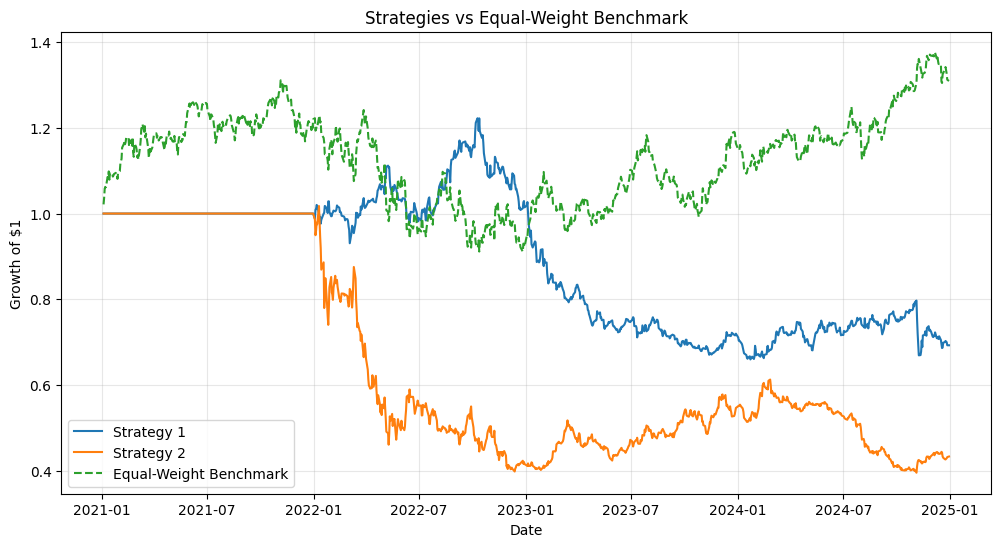

In [29]:
benchmark = ret_mat.mean(axis=1).fillna(0.0)
cum_bench = (1 + benchmark).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum1.index, cum1.values, label="Strategy 1")
plt.plot(cum2.index, cum2.values, label="Strategy 2")
plt.plot(cum_bench.index, cum_bench.values, label="Equal-Weight Benchmark", linestyle="--")
plt.legend()
plt.title("Strategies vs Equal-Weight Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.3)
plt.show()

In [30]:
stats1 = perf_stats(s1_daily)
stats2 = perf_stats(s2_daily)
stats_b = perf_stats(benchmark)

summary = pd.DataFrame(
    [stats1, stats2, stats_b],
    index=[
        "Strategy 1: Cluster Mean Reversion",
        "Strategy 2: Central → Peripheral",
        "Equal-Weight Benchmark"
    ]
)

summary

,Ann Return,Ann Vol,Sharpe,Max Drawdown
Strategy 1: Cluster Mean Reversion,-0.088052,0.157269,-0.559884,-0.460339
Strategy 2: Central → Peripheral,-0.189408,0.273054,-0.693663,-0.611499
Equal-Weight Benchmark,0.069983,0.200040,0.349847,-0.305076


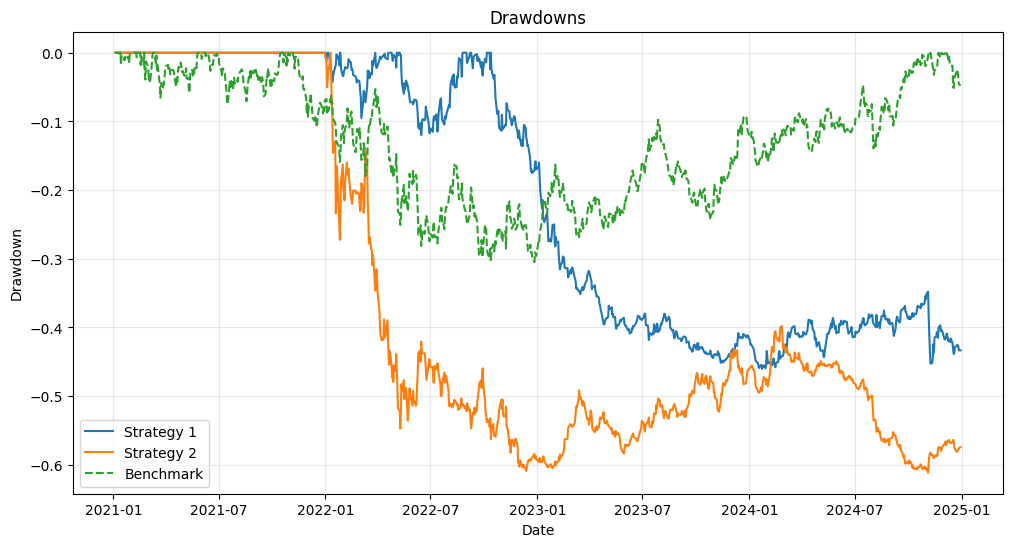

In [31]:
def drawdown_series(ret_series):
    wealth = (1 + ret_series.fillna(0.0)).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd

dd1 = drawdown_series(s1_daily)
dd2 = drawdown_series(s2_daily)
ddb = drawdown_series(benchmark)

plt.figure(figsize=(12, 6))
plt.plot(dd1.index, dd1.values, label="Strategy 1")
plt.plot(dd2.index, dd2.values, label="Strategy 2")
plt.plot(ddb.index, ddb.values, label="Benchmark", linestyle="--")
plt.legend()
plt.title("Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)
plt.show()

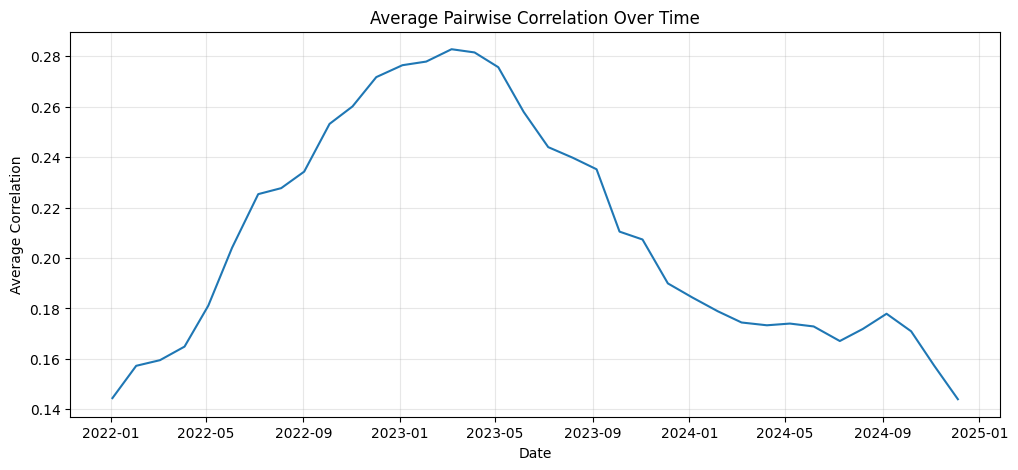

In [32]:
avg_corr_series = []

for end_loc in rebalance_points:
    window_returns = get_window_data(ret_mat, end_loc, LOOKBACK)
    if window_returns.shape[1] < 10:
        continue

    corr_t = compute_corr(window_returns)
    vals = corr_t.values[np.triu_indices_from(corr_t.values, k=1)]
    avg_corr_series.append((dates[end_loc], np.nanmean(vals)))

avg_corr_series = pd.DataFrame(avg_corr_series, columns=["date", "avg_corr"]).set_index("date")

plt.figure(figsize=(12, 5))
plt.plot(avg_corr_series.index, avg_corr_series["avg_corr"])
plt.title("Average Pairwise Correlation Over Time")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.grid(alpha=0.3)
plt.show()

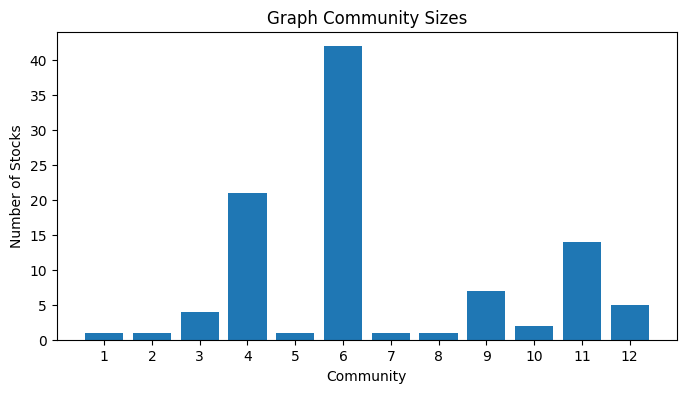

In [33]:
community_sizes = cluster_map_g.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(community_sizes.index.astype(str), community_sizes.values)
plt.title("Graph Community Sizes")
plt.xlabel("Community")
plt.ylabel("Number of Stocks")
plt.show()

In [34]:
summary.to_csv("strategy_summary.csv")
s1_daily.to_csv("strategy1_daily_returns.csv")
s2_daily.to_csv("strategy2_daily_returns.csv")
benchmark.to_csv("benchmark_daily_returns.csv")
centrality_df.to_csv("centrality_snapshot.csv")
cluster_compare.to_csv("cluster_comparison_snapshot.csv")

In [35]:
notes = """
1. A rolling stock correlation network was built using daily close-to-close returns.
2. Nodes represent stocks and edges represent strong positive return correlations.
3. Hierarchical clustering and graph community detection were used to identify groups of related stocks.
4. Network structure was compared with industry labels such as HSICMG or SICCD.
5. Strategy 1 traded mean reversion within network communities.
6. Strategy 2 tested whether central hub stocks lead lower-centrality peripheral stocks.
7. Performance was evaluated using cumulative return, annualized return, volatility, Sharpe ratio, and drawdown.
"""
print(notes)


1. A rolling stock correlation network was built using daily close-to-close returns.
2. Nodes represent stocks and edges represent strong positive return correlations.
3. Hierarchical clustering and graph community detection were used to identify groups of related stocks.
4. Network structure was compared with industry labels such as HSICMG or SICCD.
5. Strategy 1 traded mean reversion within network communities.
6. Strategy 2 tested whether central hub stocks lead lower-centrality peripheral stocks.
7. Performance was evaluated using cumulative return, annualized return, volatility, Sharpe ratio, and drawdown.



In [36]:
ideas = [
    "Use absolute return correlation to build a volatility network",
    "Use partial correlation instead of simple correlation",
    "Add transaction costs",
    "Use next-day only holding instead of monthly hold after rebalance",
    "Build sector-neutral versions of the strategies",
    "Test multiple thresholds and lookback windows",
]
for x in ideas:
    print("-", x)

- Use absolute return correlation to build a volatility network
- Use partial correlation instead of simple correlation
- Add transaction costs
- Use next-day only holding instead of monthly hold after rebalance
- Build sector-neutral versions of the strategies
- Test multiple thresholds and lookback windows
